In [85]:
import geemap
import ee
import pandas as pd
import geopandas as gpd
import rasterio as rio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Authenticate once in this machine/session before running the notebook end-to-end.
ee.Authenticate()
ee.Initialize(
    project='ee-gabriel-495521',
    opt_url='https://earthengine-highvolume.googleapis.com',
)

# Set the path to the JSON file containing the geometry.
path_json = "../data/bacias_meso_SF.geojson"
gdf = gpd.read_file(path_json)
gdf_menor = gdf[gdf['nm_mesoRH'] == 'Baixo São Francisco']
geom_ee = geemap.geopandas_to_ee(gdf_menor)
area = geom_ee.geometry()

# 3. Carregar a coleção MODIS (Reflectância de Superfície)
modis = ee.ImageCollection('MODIS/061/MOD09A1') \
    .filterBounds(area) \
    .filterDate('2000-02-18', '2025-12-31')

In [4]:
# Função para calcular o BSI (Bare Soil Index)
def bsi_index(image):
    # Aplicar fator de escala do MODIS para obter a reflectância real
    img_scaled = image.multiply(0.0001)

    # Cálculo do BSI usando .expression()
    # O BSI realça o solo exposto ao contrastar o SWIR/RED com o NIR/BLUE
    bsi = img_scaled.expression(
        '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))', {
            'BLUE': img_scaled.select('sur_refl_b03'), # Banda 3 do MODIS (Azul)
            'RED':  img_scaled.select('sur_refl_b01'), # Banda 1 do MODIS (Vermelho)
            'NIR':  img_scaled.select('sur_refl_b02'), # Banda 2 do MODIS (Infravermelho Próximo)
            'SWIR': img_scaled.select('sur_refl_b06')  # Banda 6 do MODIS (Infravermelho de Ondas Curtas)
        }
    ).rename('BSI')

    # Adiciona a banda BSI à imagem original e mantém as propriedades de data
    return image.addBands(bsi).copyProperties(image, ['system:time_start'])




In [5]:
# 5. Mapear a função sobre toda a coleção de imagens
modis_processado = modis.map(bsi_index)

In [6]:
# 1. Inicializar o XEE
import xarray as xr
from xee import helpers
import geopandas as gpd


aoi = gdf_menor.geometry.union_all()

# Definir parâmetros para fit da geometria
CRS = 'EPSG:4326'
GRID_SCALE = (0.005, -0.005)

grid_params = helpers.fit_geometry(
    geometry=aoi,
    geometry_crs=CRS,
    grid_crs=CRS,
    grid_scale=GRID_SCALE,
)

# Filtrar a coleção apenas com as bandas de interesse (MSAVI e Albedo)
modis_processado = modis_processado.select(['BSI'])

# Abre a coleção do GEE como um cubo de dados multidimensional
ds = xr.open_dataset(
    modis_processado,
    engine='ee',
    **grid_params,
    chunks='auto',
)


In [26]:
ds

<xarray.Dataset> Size: 755MB
Dimensions:  (time: 1189, y: 467, x: 340)
Coordinates:
  * time     (time) datetime64[ms] 10kB 2000-02-18 2000-02-26 ... 2025-12-27
  * y        (y) float64 4kB -8.312 -8.318 -8.322 ... -10.63 -10.64 -10.64
  * x        (x) float64 3kB -38.0 -37.99 -37.99 -37.98 ... -36.31 -36.31 -36.3
Data variables:
    BSI      (time, y, x) float32 755MB dask.array<chunksize=(192, 467, 340), meta=np.ndarray>

In [27]:
ds.to_netcdf('../data/bsi_solo_exposto.nc')

In [28]:
# Carregar dataset com os indices de desertificação
ds_ddi = xr.open_dataset('../data/indices_desertificacao_anual.nc', engine='netcdf4')
ds_bsi = xr.open_dataset('../data/bsi_solo_exposto.nc')


In [29]:
bsi_anual = ds_bsi['BSI'].groupby('time.year').median(dim='time')

### 1. Método Estatístico: Histograma e Algoritmo de Otsu

O limiar estatístico ótimo encontrado foi: 0.015


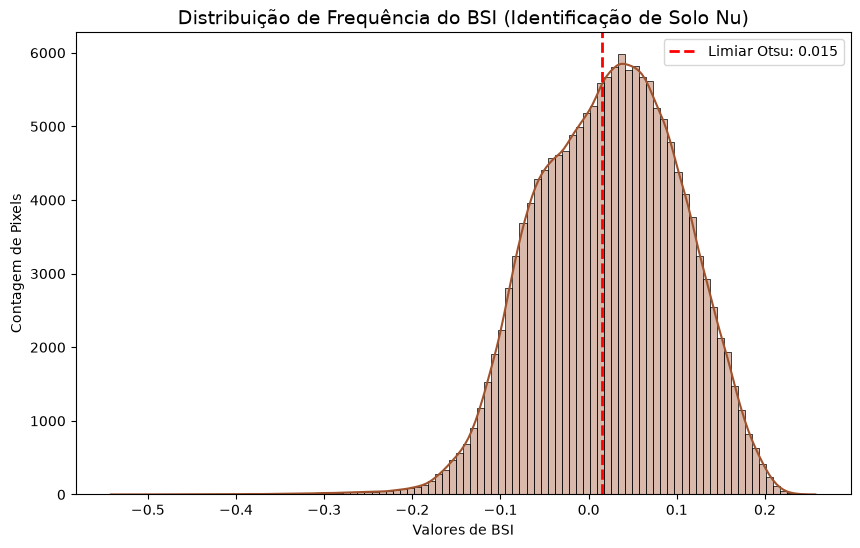

In [43]:
from skimage.filters import threshold_otsu
import numpy as np

# 1. Selecionamos um ano específico para calibrar (ou a média da série)
# Flatten transforma a matriz 2D em uma lista de valores 1D
bsi_amostra = bsi_anual.sel(year=2020).values.flatten()

# 2. Removemos os valores nulos (NaNs) para a função matemática rodar
bsi_limpo = bsi_amostra[~np.isnan(bsi_amostra)]

# 3. Calcula o limiar automático de Otsu
limiar_otsu = threshold_otsu(bsi_limpo)
print(f"O limiar estatístico ótimo encontrado foi: {limiar_otsu:.3f}")

# 4. Plotagem do Histograma para conferência
plt.figure(figsize=(10, 6))
sns.histplot(bsi_limpo, bins=100, kde=True, color='sienna', alpha=0.4)
plt.axvline(limiar_otsu, color='red', linestyle='--', linewidth=2, 
            label=f'Limiar Otsu: {limiar_otsu:.3f}')

plt.title('Distribuição de Frequência do BSI (Identificação de Solo Nu)', fontsize=14)
plt.xlabel('Valores de BSI')
plt.ylabel('Contagem de Pixels')
plt.legend()
plt.show()

### 2. Método "Ground Truth": Cruzamento com MapBiomas

In [59]:
# 3. Carregar a Coleção do MapBiomas (Coleção 8)
mapbiomas = ee.ImageCollection("projects/mapbiomas-public/assets/brazil/lulc/v1").filterBounds(area).filterDate('2000-01-01', '2025-12-31')


# Abre a coleção do GEE como um cubo de dados multidimensional
ds_mapbiomas = xr.open_dataset(
    mapbiomas,
    engine='ee',
    **grid_params,
    chunks='auto',
)

classes = [ 23, 25, 29, 30]  # Classes de interesse: 22-Área sem vegetação, 23-Praia, duna e área de areia, 25-Outras áreas não vegetadas, 30-Mineração, 29-Afloramento rochosoo
mascara_solo = xr.where(ds_mapbiomas['classification'].isin(classes), 1, 0)



In [63]:


# 2. Aplica a máscara sobre o seu dataset do BSI
bsi_solo_confirmado = ds_bsi['BSI'].where(mascara_solo == 1)

# 3. Solução do Erro: Isolar um ano (ex: 2020) e baixar para a memória local
# O .compute() tira o dado do Dask e transforma num array comum na sua RAM
bsi_amostra_2020 = bsi_solo_confirmado.sel(time='2020').compute()

# 4. Extrair apenas os valores numéricos válidos (ignorando os NaNs que eram floresta/água)
valores_bsi = bsi_amostra_2020.values.flatten()
valores_validos = valores_bsi[~np.isnan(valores_bsi)]

# 5. Calcular as estatísticas usando Numpy
limiar_real = np.percentile(valores_validos, 10)
mediana_bsi = np.median(valores_validos)

print(f"Limiar de corte (P10): {limiar_real:.4f}")
print(f"Mediana do BSI para solo exposto: {mediana_bsi:.4f}")

Limiar de corte (P10): 0.0693
Mediana do BSI para solo exposto: 0.1676


In [64]:
# 1. Harmonização Temporal: Transformar o BSI de "todas as datas" para "Anual"
# Calculamos a mediana de todas as imagens dentro de cada ano
bsi_anual = ds_bsi['BSI'].groupby('time.year').median(dim='time')

# 2. Binarizar o BSI Anual
# Se a mediana do ano for maior que o limiar, consideramos que foi um "Ano de Solo Exposto"
limiar_bsi = 0.1676 
bsi_binario_anual = xr.where(bsi_anual > limiar_bsi, 1, 0)

# 3. Calcular a Persistência (Soma dos anos expostos)
# O resultado será um mapa 2D (apenas X e Y) contendo o total de anos
persistencia = bsi_binario_anual.sum(dim='year')

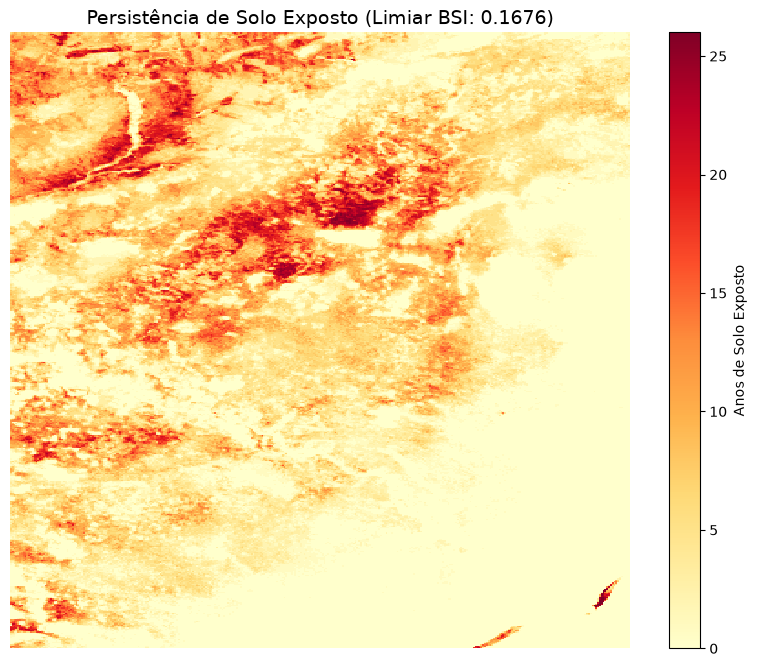

In [69]:
# 1. Definir o limiar cientificamente validado
limiar_estatistico = 0.1676

# 2. Harmonização Temporal: Tirar a mediana do BSI por ano 
# (Garante que o pixel passou a maior parte do ano como solo exposto)
bsi_anual = ds_bsi['BSI'].groupby('time.year').median(dim='time')

# 3. Binarização: 1 para Solo Exposto Crônico, 0 para o resto
bsi_binario = xr.where(bsi_anual >= limiar_estatistico, 1, 0)

# 4. Cálculo da Persistência (Soma de todos os anos da série)
# Se a série tem 25 anos, o pixel pode variar de 0 (nunca exposto) a 25 (exposição total)
persistencia_solo = bsi_binario.sum(dim='year')

# 5. Visualização rápida do resultado
plt.figure(figsize=(10, 8))
persistencia_solo.plot(cmap='YlOrRd', cbar_kwargs={'label': 'Anos de Solo Exposto'})
plt.title('Persistência de Solo Exposto (Limiar BSI: 0.1676)', fontsize=14)
plt.axis('off')
plt.show()

In [65]:
# 4. Calcular o DDI Médio Histórico
# O ds_ddi já é anual, então apenas tiramos a média ao longo do tempo.
# Verifique se a dimensão de tempo do seu ds_ddi chama 'year' ou 'time'
dim_tempo_ddi = 'year' if 'year' in ds_ddi.dims else 'time'
ddi_medio = ds_ddi['DDI'].mean(dim=dim_tempo_ddi)

# 5. Garantir o alinhamento espacial das duas matrizes 2D
persistencia, ddi_medio = xr.align(persistencia, ddi_medio, join='inner')

# 6. Preparar os dados para o gráfico
df_validacao = pd.DataFrame({
    'Anos_Solo_Exposto': persistencia.values.flatten(),
    'DDI_Medio': ddi_medio.values.flatten()
})

# Remover os NaNs
df_validacao = df_validacao.dropna()

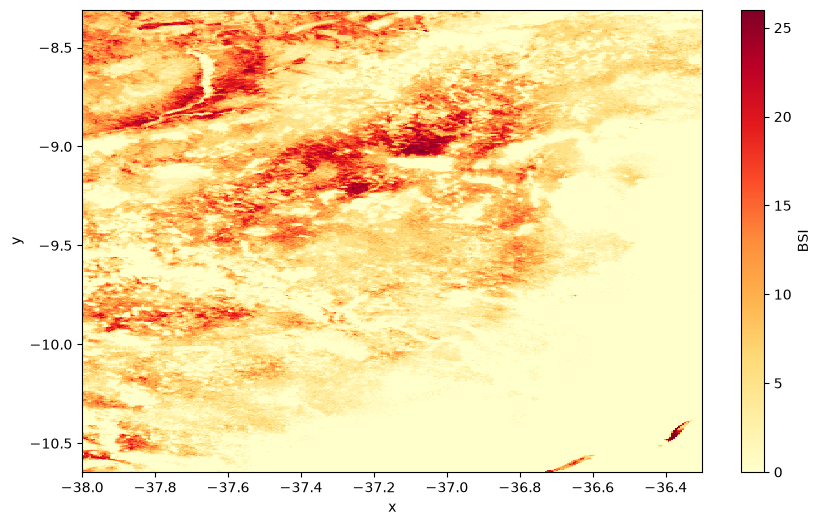

In [66]:
persistencia.plot(cmap='YlOrRd', figsize=(10, 6))

In [70]:
# Exportar a camada de persistencia em .tif para abrir no qgis.
persistencia.rio.to_raster('../data/persistencia_solo_exposto.tif')


/tmp/ipykernel_3987/2790441274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


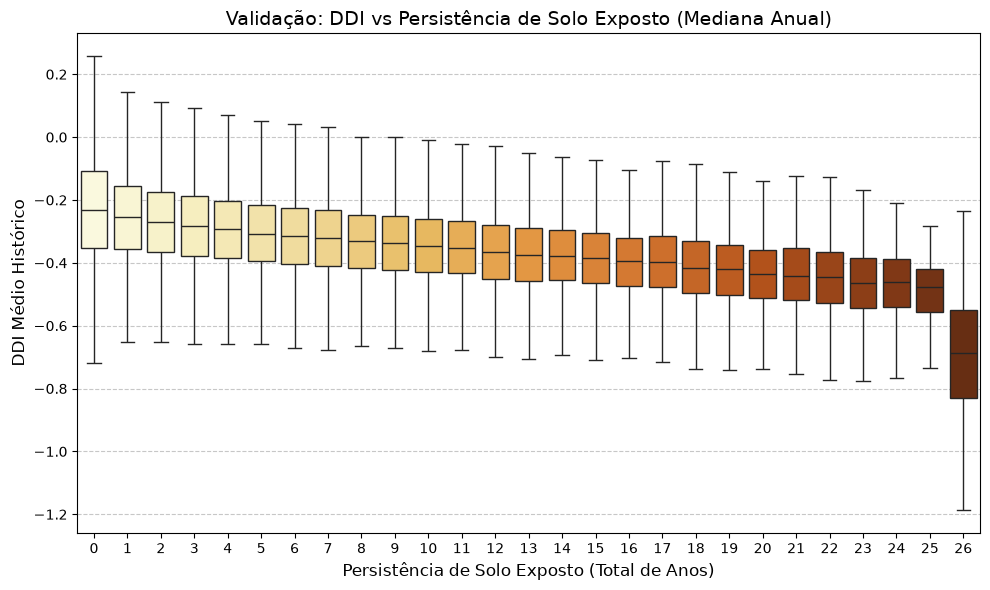

In [67]:
# 7. Plotar o Boxplot da Validação
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_validacao, 
    x='Anos_Solo_Exposto', 
    y='DDI_Medio', 
    palette='YlOrBr', 
    showfliers=False 
)

plt.title('Validação: DDI vs Persistência de Solo Exposto (Mediana Anual)', fontsize=14)
plt.xlabel('Persistência de Solo Exposto (Total de Anos)', fontsize=12)
plt.ylabel('DDI Médio Histórico', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [71]:
ddi, bsi = xr.align(ds_ddi['DDI'], bsi_anual, join='inner')

In [75]:
import xarray as xr

In [76]:
# Opção A: Correlação de Pearson (Linear)
mapa_pearson = xr.corr(ddi, bsi, dim='year')

# Opção B: Correlação de Spearman (Monotônica / Ordinal)
# Transforma os valores em posições de ranking e depois correlaciona
mapa_spearman = xr.corr(ddi.rank(dim='year'), bsi.rank(dim='year'), dim='year')

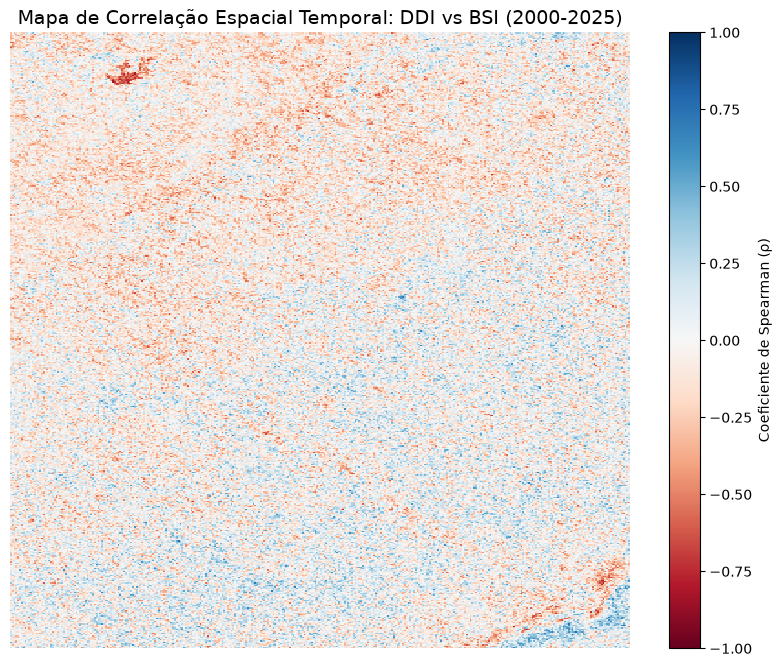

In [78]:
plt.figure(figsize=(10, 8))

# Como esperamos uma relação inversamente proporcional (mais BSI = menos DDI),
# o mapa deve tender para valores negativos (vermelho escuro).
# O cmap 'RdBu' (Red-Blue) é o padrão para mapas de correlação (-1 a +1)
mapa_spearman.plot(
    cmap='RdBu', 
    vmin=-1, 
    vmax=1, 
    cbar_kwargs={'label': 'Coeficiente de Spearman (ρ)'}
)

plt.title('Mapa de Correlação Espacial Temporal: DDI vs BSI (2000-2025)', fontsize=14)
plt.axis('off')
plt.show()

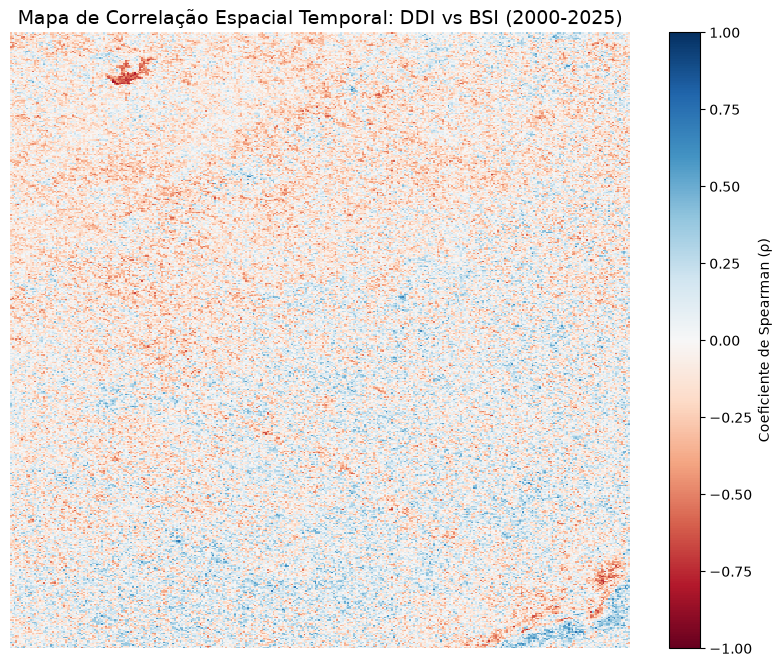

In [104]:
plt.figure(figsize=(10, 8))

# Como esperamos uma relação inversamente proporcional (mais BSI = menos DDI),
# o mapa deve tender para valores negativos (vermelho escuro).
# O cmap 'RdBu' (Red-Blue) é o padrão para mapas de correlação (-1 a +1)
mapa_pearson.plot(
    cmap='RdBu', 
    vmin=-1, 
    vmax=1, 
    cbar_kwargs={'label': 'Coeficiente de Spearman (ρ)'}
)

plt.title('Mapa de Correlação Espacial Temporal: DDI vs BSI (2000-2025)', fontsize=14)
plt.axis('off')
plt.show()

In [ ]:
# Outras etapas de validação
# Validar com os dados de LST
# Dados de nutrientes no solo
# Salinização
# Precipitação
# Evapotranspiração
# Indice de Aridez

In [109]:
# --- 1. Carregar a coleção TerraClimate para a sua área ---
# Filtrando uma série histórica longa para obter médias climatológicas estáveis
terraclimate = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE') \
    .filterBounds(area) \
    .filterDate('2000-01-01', '2025-12-31')

# --- 2. Calcular os Totais Anuais Médios ---
# O TerraClimate armazena dados mensais. Primeiro somamos os meses de cada ano 
# e depois tiramos a média de todos os anos da série.
def calcular_totais_anuais(ano):
    ano_num = ee.Number(ano)
    filtro_ano = terraclimate.filter(ee.Filter.calendarRange(ano_num, ano_num, 'year'))
    
    # Soma os 12 meses daquele ano específico
    precip_ano = filtro_ano.select('pr').sum()
    pet_ano = filtro_ano.select('pet').sum()
    
    return ee.Image.cat([precip_ano, pet_ano]).set('year', ano_num)

# Lista de anos analisados
anos = ee.List.sequence(2000, 2024)
colecao_anual = ee.ImageCollection(anos.map(calcular_totais_anuais))

# Média climatológica dos totais anuais (Redução espacial)
climatologia = colecao_anual.mean().clip(area)

# --- 3. Calcular o Índice de Aridez (P / ETP) ---
# Nota: O TerraClimate armazena a ETP (pet) com fator de escala 1. P (pr) também.
indice_aridez = climatologia.expression(
    'P / ETP', {
        'P': climatologia.select('pr'),
        'ETP': climatologia.select('pet')
    }
).rename('IA')




In [110]:
# --- 1. Carregar a coleção TerraClimate para a sua área ---
terraclimate = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE') \
    .filterBounds(area) \
    .filterDate('2000-01-01', '2025-12-31')

# --- 2 e 3. Calcular os Totais e o IA por Ano ---
# O cálculo do IA entra no fluxo de cada ano individualmente
def calcular_totais_anuais(ano):
    ano_num = ee.Number(ano)
    filtro_ano = terraclimate.filter(ee.Filter.calendarRange(ano_num, ano_num, 'year'))
    
    # Soma os 12 meses daquele ano específico
    precip_ano = filtro_ano.select('pr').sum()
    pet_ano = filtro_ano.select('pet').sum()
    
    # Calcula o IA diretamente para aquele ano dividindo P por ETP
    ia_ano = precip_ano.divide(pet_ano).rename('IA')
    
    # IMPORTANTE: Definir o time_start é essencial para manter a dimensão temporal 
    # quando você for exportar e abrir isso como um cubo de dados depois
    data_inicio = ee.Date.fromYMD(ano_num, 1, 1).millis()
    
    return ia_ano.clip(area).set({
        'year': ano_num,
        'system:time_start': data_inicio
    })

# Lista de anos analisados
anos = ee.List.sequence(2000, 2024)

# Coleção final com a série histórica completa (25 imagens, uma por ano)
colecao_ia_anual = ee.ImageCollection(anos.map(calcular_totais_anuais))

In [111]:
# Abre a coleção do GEE como um cubo de dados multidimensional
ds = xr.open_dataset(
    colecao_ia_anual,
    engine='ee',
    **grid_params,
    chunks='auto',
)


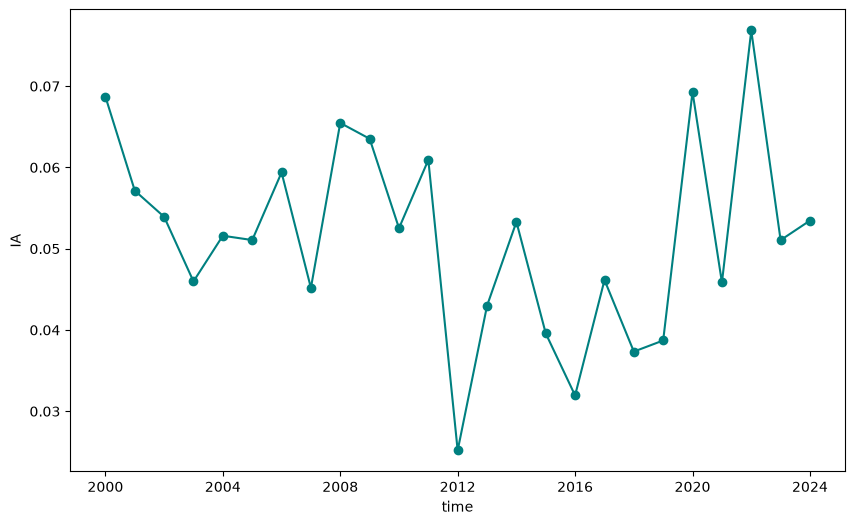

In [118]:
# Plotar a série histórica linha
ds['IA'].mean(dim=['x', 'y']).plot(figsize=(10, 6), marker='o', color='teal')

In [121]:
# Analisar a tendência por pixel e slope
ds['IA'].polyfit(dim='time', deg=1).sel(degree=1)['coefficients'].plot(
    figsize=(10, 6),
    cmap='RdBu',
    cbar_kwargs={'label': 'Slope do IA (Tendência Anual)'})

KeyError: "No variable named 'coefficients'. Did you mean one of ('polyfit_coefficients',)?"

In [115]:
ds.to_netcdf('../data/indice_aridez_serie.nc')

In [116]:
# 1. Carregar os dados (corrigindo o nome da variável do dataset)
indice_aridez = xr.open_dataset('../data/indice_aridez.nc')

# 2. Analisar a série histórica e linha de tendência, 
# p-valor em um gráfico de dispersão e ao lado um gráfico de linha com a média anual do índice de aridez 

indice_aridez['IA'].mean(dim=['x', 'y']).plot(cmap='turbo_r', figsize=(10, 6), cbar_kwargs={'label': 'Índice de Aridez (P/ETP)'})



TypeError: No numeric data to plot.

2. Classes Oficiais de AridezIntervalo do IACategoriaSuscetibilidade à DesertificaçãoIA < 0.05HiperáridoClima extremo (desertos natos)0.05 ≤ IA < 0.20ÁridoMuito Alta0.20 ≤ IA < 0.50SemiáridoAlta (Foco principal no Nordeste/SF)0.50 ≤ IA < 0.65Subúmido SecoModerada a AltaIA ≥ 0.65Subúmido Úmido / ÚmidoNão suscetível

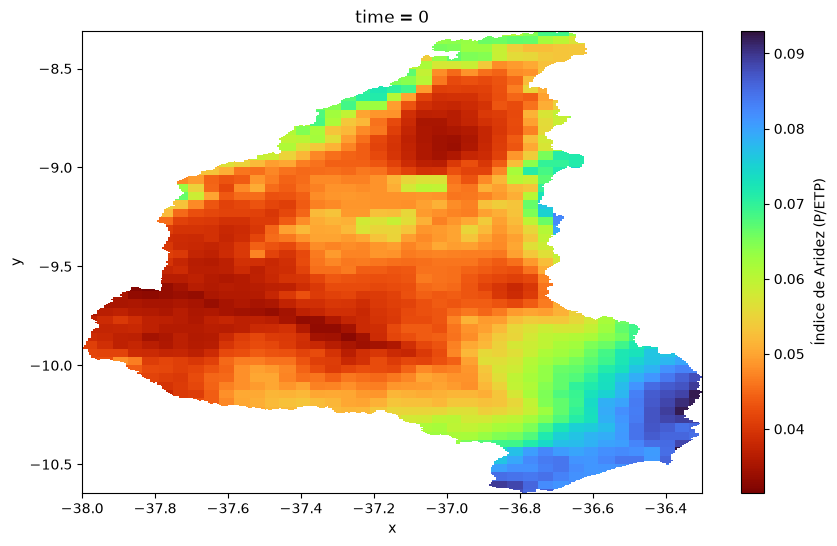

In [102]:
# Inverter a paleta de cores
indice_aridez['IA'].plot(cmap='turbo_r', figsize=(10, 6), cbar_kwargs={'label': 'Índice de Aridez (P/ETP)'})